# Objectives
After completing this lab, you will be able to:

Use scikit-learn to implement multiple linear regression
Create, train, and test a multiple linear regression model on real data

# Import needed packages
For this lab, you will need to have the following packages:

1.NumPy
2.Matplotlib
3.Pandas
4.Scikit-learn

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

# Load the dataset

In [2]:
df = pd.read_csv("./my1995-2014-fuel-consumption-ratings-5-cycle.csv")

In [3]:
df

,Model year,Make,Model,Vehicle class,Engine size (L),Cylinders,Transmission,Fuel type,City (L/100 km),Highway (L/100 km),Combined (L/100 km),Combined (mpg),CO2 emissions (g/km),CO2 rating,Smog rating
0,1995,Acura,Integra,Subcompact,1.8,4,A4,X,11.6,8.3,10.1,28,232,NaN,NaN
1,1995,Acura,Integra,Subcompact,1.8,4,M5,X,11.0,8.3,9.8,29,225,NaN,NaN
2,1995,Acura,Integra GS-R,Subcompact,1.8,4,M5,Z,10.8,8.3,9.7,29,223,NaN,NaN
3,1995,Acura,Legend,Compact,3.2,6,A4,Z,14.2,10.5,12.5,23,288,NaN,NaN
4,1995,Acura,Legend Coupe,Compact,3.2,6,A4,Z,14.6,11.0,13.0,22,299,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17848,2014,Volvo,XC60 AWD,Sport utility vehicle: Small,3.0,6,AS6,X,13.4,9.8,11.8,24,271,NaN,NaN
17849,2014,Volvo,XC60 AWD,Sport utility vehicle: Small,3.2,6,AS6,X,13.2,9.5,11.5,25,264,NaN,NaN
17850,2014,Volvo,XC70 AWD,Sport utility vehicle: Small,3.0,6,AS6,X,13.4,9.8,11.8,24,271,NaN,NaN
17851,2014,Volvo,XC70 AWD,Sport utility vehicle: Small,3.2,6,AS6,X,12.9,9.3,11.3,25,260,NaN,NaN


In [4]:
dataset = df.copy()

In [5]:
# verify successful load with some randomly selected records
dataset.sample(5)

,Model year,Make,Model,Vehicle class,Engine size (L),Cylinders,Transmission,Fuel type,City (L/100 km),Highway (L/100 km),Combined (L/100 km),Combined (mpg),CO2 emissions (g/km),CO2 rating,Smog rating
6681,2004,Ford,Crown Victoria,Full-size,4.6,8,A4,X,15.5,10.3,13.2,21,304,NaN,NaN
7742,2005,GMC,K1500 Yukon 4X4,Sport utility vehicle,4.8,8,A4,X,17.0,13.0,15.2,19,350,NaN,NaN
14669,2012,Audi,TTS Roadster,Two-seater,2.0,4,AS6,Z,11.5,8.8,10.3,27,237,NaN,NaN
12443,2009,Volkswagen,Jetta Wagon,Station wagon: Small,2.5,5,AS6,X,11.9,8.6,10.4,27,239,NaN,NaN
15014,2012,Ford,Fusion FFV AWD,Mid-size,3.0,6,AS6,X,13.4,9.3,11.5,25,265,NaN,NaN


# Explore and select features
Let's select a few features to work with that might be predictive of CO2 emissions.

In [6]:
dataset.describe()

,Model year,Engine size (L),Cylinders,City (L/100 km),Highway (L/100 km),Combined (L/100 km),Combined (mpg),CO2 emissions (g/km),CO2 rating,Smog rating
count,17853.000000,17853.000000,17853.000000,17853.000000,17853.000000,17853.000000,17853.000000,17853.000000,0.0,0.0
mean,2005.508262,3.449885,5.948468,14.547393,10.478805,12.716882,23.611270,287.205176,NaN,NaN
std,5.689300,1.326597,1.752572,3.709201,2.662348,3.202425,6.001112,65.637391,NaN,NaN
min,1995.000000,0.800000,2.000000,4.500000,4.000000,4.500000,10.000000,104.000000,NaN,NaN
25%,2001.000000,2.400000,4.000000,12.000000,8.700000,10.600000,19.000000,242.000000,NaN,NaN
50%,2006.000000,3.300000,6.000000,14.000000,9.800000,12.200000,23.000000,278.000000,NaN,NaN
75%,2010.000000,4.300000,8.000000,16.700000,12.100000,14.600000,27.000000,329.000000,NaN,NaN
max,2014.000000,8.400000,16.000000,33.300000,22.100000,27.500000,63.000000,633.000000,NaN,NaN


Notice that some of the variables are not included in the description. This is because they aren't numerical. In practice, you would analyze these features if required to improve the accuracy of your model. 
In the interest of time, you can omit this step here.
# Notice 
also that MODELYEAR is the same for all cars, so you can drop these variables for this modeling illustration.

In [7]:
# Drop categoricals and any unseless columns
dataset = dataset.drop(['Model year', 'Make', 'Model', 'Vehicle class', 'Transmission', 'Fuel type',],axis=1)

Now that you have eliminated some features, take a look at the relationships among the remaining features.

Analyzing a correlation matrix that displays the pairwise correlations between all features indicates the level of independence between them.

It also indicates how predictive each feature is of the target.

You want to eliminate any strong dependencies or correlations between features by selecting the best one from each correlated group.

In [8]:
dataset.corr()

,Engine size (L),Cylinders,City (L/100 km),Highway (L/100 km),Combined (L/100 km),Combined (mpg),CO2 emissions (g/km),CO2 rating,Smog rating
Engine size (L),1.000000,0.901907,0.822870,0.770253,0.812229,-0.780045,0.827318,NaN,NaN
Cylinders,0.901907,1.000000,0.785877,0.699369,0.762076,-0.729257,0.784474,NaN,NaN
City (L/100 km),0.822870,0.785877,1.000000,0.953111,0.993513,-0.933880,0.921097,NaN,NaN
Highway (L/100 km),0.770253,0.699369,0.953111,1.000000,0.981183,-0.901988,0.902499,NaN,NaN
Combined (L/100 km),0.812229,0.762076,0.993513,0.981183,1.000000,-0.932293,0.924332,NaN,NaN
Combined (mpg),-0.780045,-0.729257,-0.933880,-0.901988,-0.932293,1.000000,-0.907098,NaN,NaN
CO2 emissions (g/km),0.827318,0.784474,0.921097,0.902499,0.924332,-0.907098,1.000000,NaN,NaN
CO2 rating,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Smog rating,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Look at the bottom row, which shows the correlation between each variable and the target, 'CO2 emissions (g/km)'. Each of these shows a fairly high level of correlation, each exceeding 85% in magnitude. Thus all of these features are good candidates.

Next, examine the correlations of the distinct pairs. 'Engine size (L)' and 'Cylinders' are highly correlated, but 'Engine size (L)' is more correlated with the target, so we can drop 'Cylinders'.

Similarly, each of the four fuel economy variables is highly correlated with each other. Since 'Combined (mpg)' is the most correlated with the target, you can drop the others: 'City (L/100 km),' 'Highway (L/100 km),' '	Combined (L/100 km).'

Notice that Combined (L/100 km)	Combined  and 	Combined (mpg) are not perfectly correlated. They should be, though, because they measure the same property in different units. In practice, you would investigate why this is the case. You might find out that some or all of the data is not useable as is.

In [9]:
dataset

,Engine size (L),Cylinders,City (L/100 km),Highway (L/100 km),Combined (L/100 km),Combined (mpg),CO2 emissions (g/km),CO2 rating,Smog rating
0,1.8,4,11.6,8.3,10.1,28,232,NaN,NaN
1,1.8,4,11.0,8.3,9.8,29,225,NaN,NaN
2,1.8,4,10.8,8.3,9.7,29,223,NaN,NaN
3,3.2,6,14.2,10.5,12.5,23,288,NaN,NaN
4,3.2,6,14.6,11.0,13.0,22,299,NaN,NaN
...,...,...,...,...,...,...,...,...,...
17848,3.0,6,13.4,9.8,11.8,24,271,NaN,NaN
17849,3.2,6,13.2,9.5,11.5,25,264,NaN,NaN
17850,3.0,6,13.4,9.8,11.8,24,271,NaN,NaN
17851,3.2,6,12.9,9.3,11.3,25,260,NaN,NaN


In [13]:
dataset = dataset.drop(['Cylinders', 'City (L/100 km)', 'Highway (L/100 km)','Combined (L/100 km)',],axis=1)

In [15]:
dataset.head(9)

,Engine size (L),Combined (mpg),CO2 emissions (g/km),CO2 rating,Smog rating
0,1.8,28,232,NaN,NaN
1,1.8,29,225,NaN,NaN
2,1.8,29,223,NaN,NaN
3,3.2,23,288,NaN,NaN
4,3.2,22,299,NaN,NaN
5,3.2,22,292,NaN,NaN
6,3.0,21,304,NaN,NaN
7,3.0,22,292,NaN,NaN
8,3.0,19,343,NaN,NaN


In [16]:
dataset

,Engine size (L),Combined (mpg),CO2 emissions (g/km),CO2 rating,Smog rating
0,1.8,28,232,NaN,NaN
1,1.8,29,225,NaN,NaN
2,1.8,29,223,NaN,NaN
3,3.2,23,288,NaN,NaN
4,3.2,22,299,NaN,NaN
...,...,...,...,...,...
17848,3.0,24,271,NaN,NaN
17849,3.2,25,264,NaN,NaN
17850,3.0,24,271,NaN,NaN
17851,3.2,25,260,NaN,NaN


In [18]:
dataset = dataset.drop(['CO2 rating', 'Smog rating'], axis=1)

To help with selecting predictive features that are not redundant, consider the following scatter matrix, which shows the scatter plots for each pair of input features. The diagonal of the matrix shows each feature's histogram.

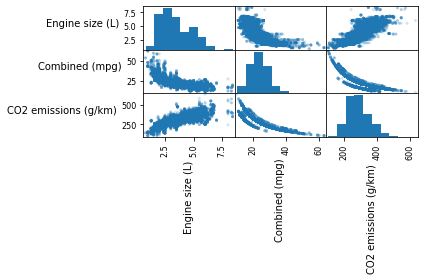

In [19]:
axes = pd.plotting.scatter_matrix(dataset, alpha=0.2)
# need to rotate axis labels so we can read them
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')

plt.tight_layout()
plt.gcf().subplots_adjust(wspace=0, hspace=0)
plt.show()

As you can see, the relationship between 'Combined (mpg)' and 'CO2 emmission (g/km)' is non-linear. In addition, you can clearly see three different curves. This suggests exploring the categorical variables to see if they are able to explain these differences. Let's leave this as an exercise for you to explore deeper. Regarding the non-linearity, you will handle this in the next lab. For now, let's just consider through modeling whether fuel economy explains some of the variances in the target as is.

In [20]:
dataset

,Engine size (L),Combined (mpg),CO2 emissions (g/km)
0,1.8,28,232
1,1.8,29,225
2,1.8,29,223
3,3.2,23,288
4,3.2,22,299
...,...,...,...
17848,3.0,24,271
17849,3.2,25,264
17850,3.0,24,271
17851,3.2,25,260


In [21]:
dataset.corr()

,Engine size (L),Combined (mpg),CO2 emissions (g/km)
Engine size (L),1.000000,-0.780045,0.827318
Combined (mpg),-0.780045,1.000000,-0.907098
CO2 emissions (g/km),0.827318,-0.907098,1.000000


# Extract the input features and labels from the data set
Extract the required columns and convert the resulting dataframes to NumPy arrays.

In [23]:
X = dataset.iloc[:,[0,1]].to_numpy()
y = dataset.iloc[:,[2]].to_numpy()

# Preprocess selected features
You should standardize your input features so the model doesn't inadvertently favor any feature due to its magnitude. The typical way to do this is to subtract the mean and divide by the standard deviation. Scikit-learn can do this for you.

In [24]:
from sklearn import preprocessing

std_scaler = preprocessing.StandardScaler()
X_std = std_scaler.fit_transform(X)

In practice, if you want to properly evaluate your model, you should definitely not apply such operations to the entire dataset but to the train and test data separately. There's more to it than that. You'll dive deeper into this and other advanced evaluation pitfalls later in the course.

In [25]:
pd.DataFrame(X_std).describe().round(2)

,0,1
count,17853.00,17853.00
mean,-0.00,0.00
std,1.00,1.00
min,-2.00,-2.27
25%,-0.79,-0.77
50%,-0.11,-0.10
75%,0.64,0.56
max,3.73,6.56


As you can see, a standardized variable has zero mean and a standard deviation of one.

# Create train and test datasets
Randomly split your data into train and test sets, using 80% of the dataset for training and reserving the remaining 20% for testing.

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_std,y,test_size=0.2,random_state=42)

# Build a multiple linear regression model
Multiple and simple linear regression models can be implemented with exactly the same scikit-learn tools.

In [27]:
from sklearn import linear_model

# create a model object
regressor = linear_model.LinearRegression()

# train the model in the training data
regressor.fit(X_train, y_train)

# Print the coefficients
coef_ =  regressor.coef_
intercept_ = regressor.intercept_

print ('Coefficients: ',coef_)
print ('Intercept: ',intercept_)

Coefficients:  [[ 19.67584453 -44.41000371]]
Intercept:  [287.17389082]


The Coefficients and Intercept parameters define the best-fit hyperplane to the data. Since there are only two variables, hence two parameters, the hyperplane is a plane. But this best-fit plane will look different in the original, unstandardized feature space.

You can transform your model's parameters back to the original space prior to standardization as follows. This gives you a proper sense of what they mean in terms of your original input features. Without these adjustments, the model's outputs would be tied to an abstract, transformed space that doesn’t align with the actual independent variables and the real-world problem you’re solving.

In [28]:
# Get the standard scaler's mean and standard deviation parameters
means_ = std_scaler.mean_
std_devs_ = np.sqrt(std_scaler.var_)

# The least squares parameters can be calculated relative to the original, unstandardized feature space as:
coef_original = coef_ / std_devs_
intercept_original = intercept_ - np.sum((means_ * coef_) / std_devs_)

print ('Coefficients: ', coef_original)
print ('Intercept: ', intercept_original)

Coefficients:  [[14.83222844 -7.40050318]]
Intercept:  [410.73968321]


You would expect that for the limiting case of zero ENGINESIZE and zero FUELCONSUMPTION_COMB_MPG, the resulting CO2 emissions should also be zero. This is inconsistent with the 'best fit' hyperplane, which has a non-zero intercept of 329 g/km. The answer must be that the target variable does not have a very strong linear relationship to the dependent variables, and/or the data has outliers that are biasing the result. Outliers can be handled in preprocessing, or as you will learn about later in the course, by using regularization techniques. One or more of the variables might have a nonlinear relationship to the target. Or there may still be some colinearity amongst the input variables.

# Visualize model outputs
You can visualize the goodness-of-fit of the model to the training data by plotting the fitted plane over the data.

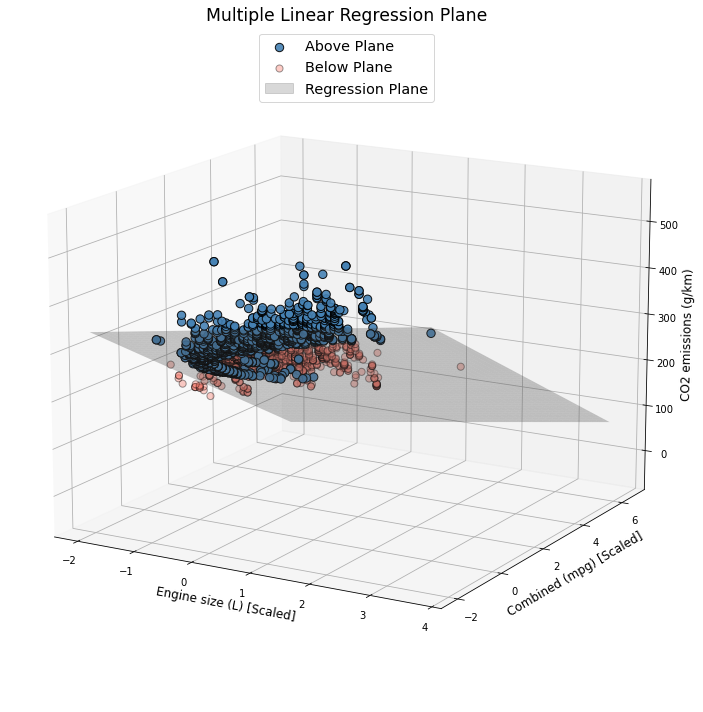

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. Prepare data for plotting
# Flattening ensures we have 1D arrays for the scatter function
X1 = X_test[:, 0].flatten()
X2 = X_test[:, 1].flatten()
y_actual = y_test.values.flatten() if hasattr(y_test, 'values') else y_test.flatten()

# 2. Create a mesh grid for the regression plane
x1_surf, x2_surf = np.meshgrid(np.linspace(X1.min(), X1.max(), 100), 
                               np.linspace(X2.min(), X2.max(), 100))

# Calculate plane Z-values (using the standardized coefficients)
y_surf = intercept_ + coef_[0, 0] * x1_surf + coef_[0, 1] * x2_surf

# 3. Handle Above/Below Plane Logic
y_pred = regressor.predict(X_test).flatten()
mask_above = y_actual >= y_pred
mask_below = y_actual < y_pred

# 4. Plotting
fig = plt.figure(figsize=(20, 10))
ax = fig.add_subplot(111, projection='3d')

# Scatter points: Above (Solid) and Below (Faded)
ax.scatter(X1[mask_above], X2[mask_above], y_actual[mask_above], 
           color='steelblue', label="Above Plane", s=70, alpha=0.9, ec='k')
ax.scatter(X1[mask_below], X2[mask_below], y_actual[mask_below], 
           color='salmon', label="Below Plane", s=50, alpha=0.4, ec='k')

# Plot the regression plane (Removed label here to prevent AttributeError)
ax.plot_surface(x1_surf, x2_surf, y_surf, color='gray', alpha=0.3)

# 5. Fix the Legend using a Proxy Artist for the Plane
plane_proxy = mpatches.Patch(color='gray', alpha=0.3, label='Regression Plane')
handles, labels = ax.get_legend_handles_labels()
handles.append(plane_proxy)
ax.legend(handles=handles, fontsize='x-large', loc='upper center')

# 6. Final Formatting
ax.view_init(elev=15, azim=-60) # Adjusted angle for better perspective
ax.set_xlabel('Engine size (L) [Scaled]', fontsize='large')
ax.set_ylabel('Combined (mpg) [Scaled]', fontsize='large')
ax.set_zlabel('CO2 emissions (g/km)', fontsize='large')
ax.set_title('Multiple Linear Regression Plane', fontsize='xx-large')

# Note: Removed set_xticks([]) so you can see the scale, 
# but you can add them back if you prefer the clean look.

plt.tight_layout()
plt.show()

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Use the predict method to make test predictions
y_pred = regressor.predict(X_test)

# Evaluation
print("Mean absolute error: %.2f" % mean_absolute_error(y_test, y_pred))
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
print("Root mean squared error: %.2f" % np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2-score: %.2f" % r2_score(y_test, y_pred))

Mean absolute error: 16.18
Mean squared error: 631.76
Root mean squared error: 25.13
R2-score: 0.85


In [41]:
# Check the first 5 predictions vs actuals
# Removed .values because y_test is already a numpy array
comparison = pd.DataFrame({
    'Actual': y_test.flatten(), 
    'Predicted': y_pred.flatten()
})

print(comparison.head())

   Actual   Predicted
0     235  240.606165
1     189  182.854141
2     334  329.459037
3     357  326.476980
4     299  277.593070


# code with error because the model is trying to fit a plane to a non-planar surface.

In [35]:
"""
#from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt

# Ensure X1, X2, and y_test have compatible shapes for 3D plotting
X1 = X_test[:, 0] if X_test.ndim > 1 else X_test
X2 = X_test[:, 1] if X_test.ndim > 1 else np.zeros_like(X1)

# Create a mesh grid for plotting the regression plane
x1_surf, x2_surf = np.meshgrid(np.linspace(X1.min(), X1.max(), 100), 
                               np.linspace(X2.min(), X2.max(), 100))

y_surf = intercept_ +  coef_[0,0] * x1_surf  +  coef_[0,1] * x2_surf

# Predict y values using trained regression model to compare with actual y_test for above/below plane colors
y_pred = regressor.predict(X_test.reshape(-1, 1)) if X_test.ndim == 1 else regressor.predict(X_test)
above_plane = y_test >= y_pred
below_plane = y_test < y_pred
above_plane = above_plane[:,0]
below_plane = below_plane[:,0]

# Plotting
fig = plt.figure(figsize=(20, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the data points above and below the plane in different colors
ax.scatter(X1[above_plane], X2[above_plane], y_test[above_plane],  label="Above Plane",s=70,alpha=.7,ec='k')
ax.scatter(X1[below_plane], X2[below_plane], y_test[below_plane],  label="Below Plane",s=50,alpha=.3,ec='k')

# Plot the regression plane
ax.plot_surface(x1_surf, x2_surf, y_surf, color='k', alpha=0.21,label='plane')

# Set view and labels
ax.view_init(elev=10)

ax.legend(fontsize='x-large',loc='upper center')
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.set_box_aspect(None, zoom=0.75)
ax.set_xlabel('Engine size (L)', fontsize='xx-large')
ax.set_ylabel('Combined (mpg)', fontsize='xx-large')
ax.set_zlabel('CO2 emissions (g/km)', fontsize='xx-large')
ax.set_title('Multiple Linear Regression of CO2 emissions (g/km)', fontsize='xx-large')
plt.tight_layout()
plt.show()"""

'\n#from mpl_toolkits.mplot3d import Axes3D\nimport numpy as np\nimport matplotlib.pyplot as plt\n\n# Ensure X1, X2, and y_test have compatible shapes for 3D plotting\nX1 = X_test[:, 0] if X_test.ndim > 1 else X_test\nX2 = X_test[:, 1] if X_test.ndim > 1 else np.zeros_like(X1)\n\n# Create a mesh grid for plotting the regression plane\nx1_surf, x2_surf = np.meshgrid(np.linspace(X1.min(), X1.max(), 100), \n                               np.linspace(X2.min(), X2.max(), 100))\n\ny_surf = intercept_ +  coef_[0,0] * x1_surf  +  coef_[0,1] * x2_surf\n\n# Predict y values using trained regression model to compare with actual y_test for above/below plane colors\ny_pred = regressor.predict(X_test.reshape(-1, 1)) if X_test.ndim == 1 else regressor.predict(X_test)\nabove_plane = y_test >= y_pred\nbelow_plane = y_test < y_pred\nabove_plane = above_plane[:,0]\nbelow_plane = below_plane[:,0]\n\n# Plotting\nfig = plt.figure(figsize=(20, 8))\nax = fig.add_subplot(111, projection=\'3d\')\n\n# Plot the d

# updated code

In [36]:
"""
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches # <--- UPDATED: Required for the legend fix

# 1. Prepare data for plotting
# UPDATED: Added .flatten() to ensure we have 1D arrays for the scatter function
X1 = X_test[:, 0].flatten()
X2 = X_test[:, 1].flatten()
y_actual = y_test.values.flatten() if hasattr(y_test, 'values') else y_test.flatten()

# 2. Create a mesh grid for the regression plane
x1_surf, x2_surf = np.meshgrid(np.linspace(X1.min(), X1.max(), 100), 
                               np.linspace(X2.min(), X2.max(), 100))

# Calculate plane Z-values (using the standardized coefficients)
y_surf = intercept_ + coef_[0, 0] * x1_surf + coef_[0, 1] * x2_surf

# 3. Handle Above/Below Plane Logic
# UPDATED: Simplified logic using .flatten() to prevent indexing errors
y_pred = regressor.predict(X_test).flatten()
mask_above = y_actual >= y_pred
mask_below = y_actual < y_pred

# 4. Plotting
fig = plt.figure(figsize=(20, 10))
ax = fig.add_subplot(111, projection='3d')

# Scatter points: Above and Below
ax.scatter(X1[mask_above], X2[mask_above], y_actual[mask_above], 
           color='steelblue', label="Above Plane", s=70, alpha=0.9, ec='k')
ax.scatter(X1[mask_below], X2[mask_below], y_actual[mask_below], 
           color='salmon', label="Below Plane", s=50, alpha=0.4, ec='k')

# --- THE CRITICAL FIX ---
# UPDATED: Removed label='plane' from here to stop the AttributeError
ax.plot_surface(x1_surf, x2_surf, y_surf, color='gray', alpha=0.3)

# UPDATED: Manually created a "Proxy" for the legend so it doesn't crash
plane_proxy = mpatches.Patch(color='gray', alpha=0.3, label='Regression Plane')
handles, labels = ax.get_legend_handles_labels()
handles.append(plane_proxy) # Adding the fake "plane" to the list of legend items
ax.legend(handles=handles, fontsize='x-large', loc='upper center')
# ------------------------

# 5. Final Formatting
ax.view_init(elev=15, azim=-60) 
ax.set_xlabel('Engine size (L) [Scaled]', fontsize='large')
ax.set_ylabel('Combined (mpg) [Scaled]', fontsize='large')
ax.set_zlabel('CO2 emissions (g/km)', fontsize='large')
ax.set_title('Multiple Linear Regression Plane', fontsize='xx-large')

plt.tight_layout()
plt.show()"""

'\nimport numpy as np\nimport matplotlib.pyplot as plt\nimport matplotlib.patches as mpatches # <--- UPDATED: Required for the legend fix\n\n# 1. Prepare data for plotting\n# UPDATED: Added .flatten() to ensure we have 1D arrays for the scatter function\nX1 = X_test[:, 0].flatten()\nX2 = X_test[:, 1].flatten()\ny_actual = y_test.values.flatten() if hasattr(y_test, \'values\') else y_test.flatten()\n\n# 2. Create a mesh grid for the regression plane\nx1_surf, x2_surf = np.meshgrid(np.linspace(X1.min(), X1.max(), 100), \n                               np.linspace(X2.min(), X2.max(), 100))\n\n# Calculate plane Z-values (using the standardized coefficients)\ny_surf = intercept_ + coef_[0, 0] * x1_surf + coef_[0, 1] * x2_surf\n\n# 3. Handle Above/Below Plane Logic\n# UPDATED: Simplified logic using .flatten() to prevent indexing errors\ny_pred = regressor.predict(X_test).flatten()\nmask_above = y_actual >= y_pred\nmask_below = y_actual < y_pred\n\n# 4. Plotting\nfig = plt.figure(figsize=(20

Instead of making a 3D plot, which is difficult to interpret, you can look at vertical slices of the 3D plot by plotting each variable separately as a best-fit line using the corresponding regression parameters.

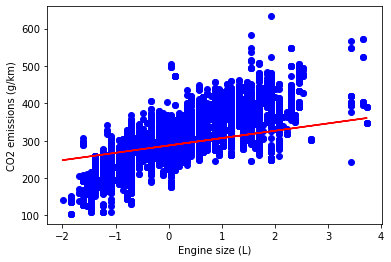

In [33]:
plt.scatter(X_train[:,0], y_train,  color='blue')
plt.plot(X_train[:,0], coef_[0,0] * X_train[:,0] + intercept_[0], '-r')
plt.xlabel("Engine size (L)")
plt.ylabel("CO2 emissions (g/km)")
plt.show()

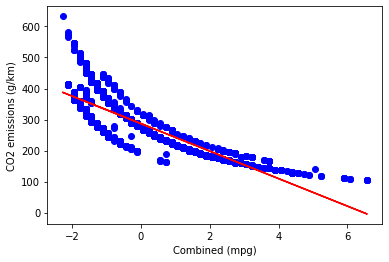

In [34]:
plt.scatter(X_train[:,1], y_train,  color='blue')
plt.plot(X_train[:,1], coef_[0,1] * X_train[:,1] + intercept_[0], '-r')
plt.xlabel("Combined (mpg)")
plt.ylabel("CO2 emissions (g/km)")
plt.show()